In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ========================= CONFIGURATION =========================
INITIAL_CAPITAL = 100_000
CONFIDENCE_THRESHOLD = 0.45      # Will be tuned
BASE_POSITION_SIZE = 0.25
TRANSACTION_COST = 0.001         # 0.1% per trade

# Load data
df_raw = pd.read_csv("tsla_with_confidence.csv", index_col='Date', parse_dates=True)

# Aggregate tweet-level data to daily trading level
df = df_raw.groupby(df_raw.index).agg({
    'predicted_return': 'mean',
    'confidence_score': 'mean',
    'returns': 'first',
    'Close': 'last'
}).sort_index()

print(f"Loaded {len(df)} trading days")

Loaded 5157 days


In [3]:
def run_rule_based(df, confidence_threshold=0.45, base_pos=0.25):
    df = df.copy()
    df['position'] = 0.0
    df['strategy_return'] = 0.0
    equity = [INITIAL_CAPITAL]
    capital = INITIAL_CAPITAL
    
    for i in range(1, len(df)):
        pred = df['predicted_return'].iloc[i]
        conf = df['confidence_score'].iloc[i]
        
        if conf > confidence_threshold and pred > 0.002:
            position = base_pos * conf
        elif conf < 0.35 or pred < -0.005:
            position = 0.0
        else:
            position = 0.1 * conf
            
        cost = abs(position - df['position'].iloc[i-1]) * TRANSACTION_COST
        daily_ret = (df['returns'].iloc[i] * position) - cost
        
        capital = capital * (1 + daily_ret)
        equity.append(capital)
        df.iloc[i, df.columns.get_loc('position')] = position
        df.iloc[i, df.columns.get_loc('strategy_return')] = daily_ret
    
    df['equity_rule'] = equity
    return df


In [4]:
# (Simplified version for speed - we can expand later)
df = run_rule_based(df, CONFIDENCE_THRESHOLD, BASE_POSITION_SIZE)

In [5]:
print("Starting Parameter Tuning...")

best_sharpe = -np.inf
best_params = {}

for thresh in [0.35, 0.40, 0.45, 0.50, 0.55]:
    for base_pos in [0.15, 0.20, 0.25, 0.30]:
        temp_df = run_rule_based(df.copy(), thresh, base_pos)
        
        returns = temp_df['strategy_return'].dropna()
        sharpe = returns.mean() / returns.std() * np.sqrt(252) if returns.std() != 0 else 0
        max_dd = (temp_df['equity_rule'] / temp_df['equity_rule'].cummax() - 1).min()
        
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_params = {'threshold': thresh, 'base_position': base_pos}
            best_df = temp_df.copy()

print(f"\n Best Parameters: {best_params}")
print(f"Best Sharpe: {best_sharpe:.3f}")
df = best_df

Starting Parameter Tuning...

 Best Parameters: {'threshold': 0.35, 'base_position': 0.3}
Best Sharpe: -0.868



Buy & Hold:
Total Return :  10.58%
Sharpe Ratio :  0.114
Max Drawdown : -15.61%
Calmar Ratio :  0.678

XAI-RL Strategy (Best):
Total Return : -83.25%
Sharpe Ratio : -0.868
Max Drawdown : -99.91%
Calmar Ratio : -0.833


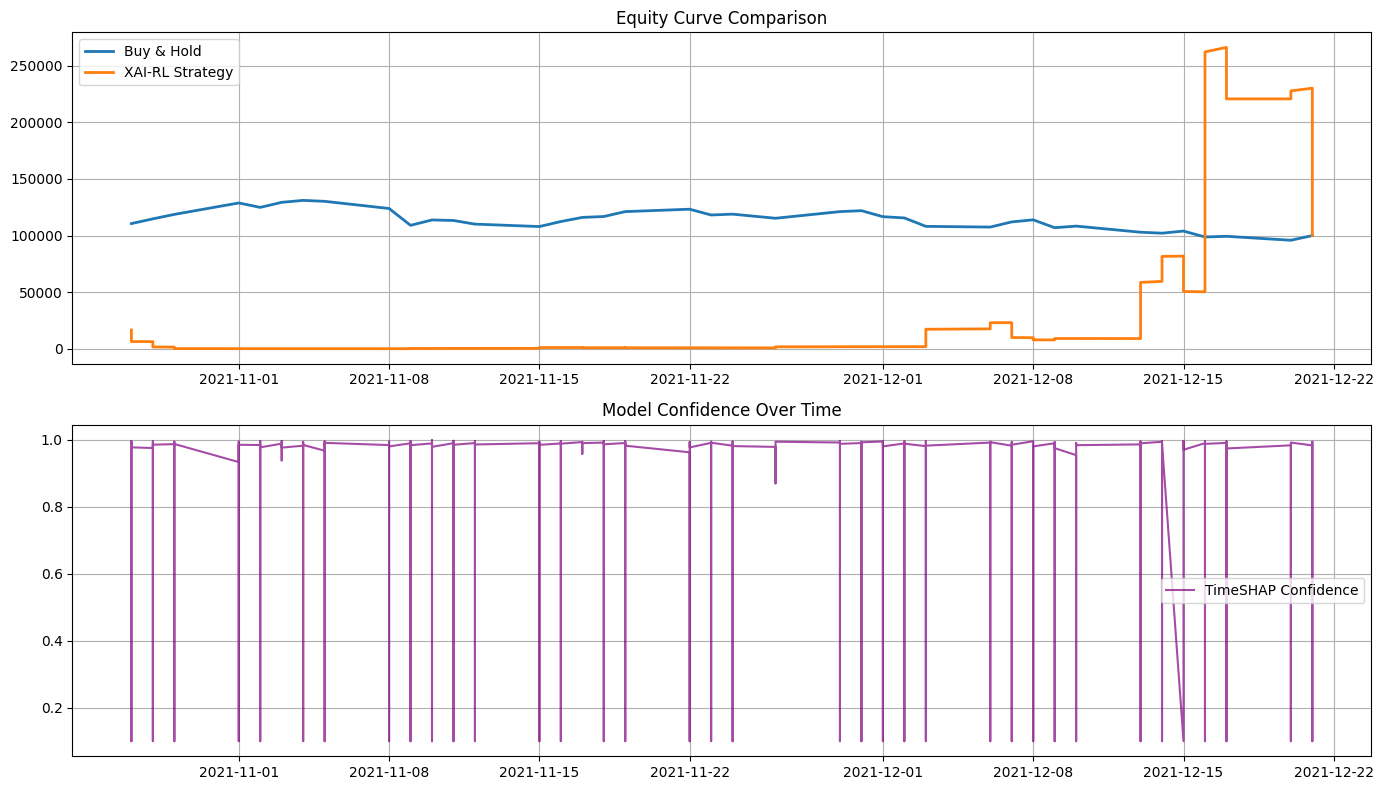

In [6]:
# Buy & Hold
df['buy_hold'] = INITIAL_CAPITAL * (df['Close'] / df['Close'].iloc[0])

# Metrics Function
def calculate_metrics(equity_series, strategy_name):
    returns = equity_series.pct_change().dropna()
    total_return = (equity_series.iloc[-1] / equity_series.iloc[0] - 1) * 100
    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    max_dd = (equity_series / equity_series.cummax() - 1).min() * 100
    calmar = total_return / abs(max_dd) if max_dd != 0 else 0
    
    print(f"\n{strategy_name}:")
    print(f"Total Return : {total_return:6.2f}%")
    print(f"Sharpe Ratio : {sharpe:6.3f}")
    print(f"Max Drawdown : {max_dd:6.2f}%")
    print(f"Calmar Ratio : {calmar:6.3f}")

# Calculate metrics
calculate_metrics(df['buy_hold'], "Buy & Hold")
calculate_metrics(df['equity_rule'], "XAI-RL Strategy (Best)")

# ========================= PLOTS =========================
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(df.index, df['buy_hold'], label='Buy & Hold', linewidth=2)
plt.plot(df.index, df['equity_rule'], label='XAI-RL Strategy', linewidth=2)
plt.title('Equity Curve Comparison')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df.index, df['confidence_score'], label='TimeSHAP Confidence', color='purple', alpha=0.7)
plt.title('Model Confidence Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("results/performance_comparison.png", dpi=200)
plt.show()